# SCC.454 Lab: Building Recommender Systems with Apache Spark

**Duration:** 2 hours
**Module:** SCC.454 – Large Scale Platforms for AI and Data Analysis  
**Lecturer:** Dr Tharindu Ranasinghe  
**Lancaster University – School of Computing and Communications**

---

## Learning Objectives

By the end of this lab, you will be able to:

1. Load and explore real-world recommendation datasets using Apache Spark
2. Build a **content-based** recommender using TF-IDF and cosine similarity in Spark
3. Build a **collaborative filtering** recommender using Spark MLlib's ALS (Alternating Least Squares)
4. Evaluate recommender systems using RMSE, precision, and coverage metrics
5. Compare the strengths and limitations of both approaches on real data

## Lab Structure

| Section | Topic | Estimated Time |
|---------|-------|----------------|
| **Part 1** | Setup & Data Exploration | 15 minutes |
| **Part 2** | Content-Based Filtering with Spark | 40 minutes |
| **Part 3** | Collaborative Filtering with ALS | 30 minutes |
| **Part 4** | Evaluation & Comparison | 20 minutes |
| **Part 5** | Extension Exercises | 10 minutes |

## Dataset

We use the [MovieLens 100K dataset](https://grouplens.org/datasets/movielens/100k/) from GroupLens Research, which contains:
- **100,000 ratings** (1–5) from **600 users** on **9,000 movies**
- Movie metadata including titles, genres, and tags

This is one of the most widely used benchmark datasets in recommender systems research.

---

# Part 1: Setup & Data Exploration

## 1.1 Environment Setup

First, let's install the required packages and initialise our Spark session.

In [1]:
# # Install required packages (run once)
# !pip install pandas matplotlib seaborn
# !pip install pyspark==3.5.0 -q
# !apt-get update
# !apt-get install openjdk-11-jdk-headless -qq > /dev/null 2>&1

# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
# print("PySpark and Java installed successfully!")

In [2]:
import os, sys
from pyspark.sql import SparkSession

# Force Spark to use *this* notebook's Python (your venv)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [3]:
# Core imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import HashingTF, IDF, Tokenizer, StringIndexer
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.linalg import Vectors, VectorUDT
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import zipfile

# Create Spark session
spark = SparkSession.builder \
    .appName("SCC454-RecommenderSystems") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

# Set log level to reduce noise
spark.sparkContext.setLogLevel("ERROR")

print(f"Spark version: {spark.version}")
print("Spark session created successfully!")

Spark version: 3.5.0
Spark session created successfully!


## 1.2 Download the MovieLens Dataset

We'll download the MovieLens "small" dataset (ml-latest-small), which is ideal for experimentation.

In [4]:
# Download MovieLens dataset
data_dir = "data"
ml_dir = os.path.join(data_dir, "ml-latest-small")

if not os.path.exists(ml_dir):
    os.makedirs(data_dir, exist_ok=True)
    url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    zip_path = os.path.join(data_dir, "ml-latest-small.zip")

    print("Downloading MovieLens dataset...")
    urllib.request.urlretrieve(url, zip_path)

    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(data_dir)

    os.remove(zip_path)
    print("Done!")
else:
    print(f"Dataset already exists at {ml_dir}")

# List downloaded files
print("\nFiles available:")
for f in os.listdir(ml_dir):
    size = os.path.getsize(os.path.join(ml_dir, f))
    print(f"  {f:20s} ({size/1024:.1f} KB)")

Dataset already exists at data\ml-latest-small

Files available:
  links.csv            (193.3 KB)
  movies.csv           (482.8 KB)
  ratings.csv          (2425.5 KB)
  README.txt           (8.1 KB)
  tags.csv             (115.9 KB)


## 1.3 Load Data into Spark DataFrames

The MovieLens dataset contains several CSV files. We'll load the three most important ones:
- **ratings.csv**: userId, movieId, rating, timestamp
- **movies.csv**: movieId, title, genres
- **tags.csv**: userId, movieId, tag, timestamp

In [5]:
# Load ratings
ratings = spark.read.csv(
    os.path.join(ml_dir, "ratings.csv"),
    header=True,
    inferSchema=True
)

# Load movies
movies = spark.read.csv(
    os.path.join(ml_dir, "movies.csv"),
    header=True,
    inferSchema=True
)

# Load tags
tags = spark.read.csv(
    os.path.join(ml_dir, "tags.csv"),
    header=True,
    inferSchema=True
)

# Display schemas
print("=== Ratings ===")
ratings.printSchema()
ratings.show(5, truncate=False)

print("\n=== Movies ===")
movies.printSchema()
movies.show(5, truncate=False)

print("\n=== Tags ===")
tags.printSchema()
tags.show(5, truncate=False)

=== Ratings ===
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|
|1     |3      |4.0   |964981247|
|1     |6      |4.0   |964982224|
|1     |47     |5.0   |964983815|
|1     |50     |5.0   |964982931|
+------+-------+------+---------+
only showing top 5 rows


=== Movies ===
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fant

## 1.4 Exploratory Data Analysis

Before building models, let's understand the data. This is crucial — the **sparsity** of the utility matrix is the fundamental challenge that motivates different recommendation approaches.

In [6]:
# Basic statistics
num_ratings = ratings.count()
num_users = ratings.select("userId").distinct().count()
num_movies = ratings.select("movieId").distinct().count()
total_movies = movies.count()

# Sparsity: what fraction of the utility matrix is filled?
sparsity = 1.0 - (num_ratings / (num_users * num_movies))

print(f"Number of ratings:       {num_ratings:,}")
print(f"Number of users:         {num_users:,}")
print(f"Number of rated movies:  {num_movies:,}")
print(f"Total movies in catalog: {total_movies:,}")
print(f"Average ratings/user:    {num_ratings/num_users:.1f}")
print(f"Average ratings/movie:   {num_ratings/num_movies:.1f}")
print(f"Utility matrix sparsity: {sparsity:.4%}")

Number of ratings:       100,836
Number of users:         610
Number of rated movies:  9,724
Total movies in catalog: 9,742
Average ratings/user:    165.3
Average ratings/movie:   10.4
Utility matrix sparsity: 98.3000%


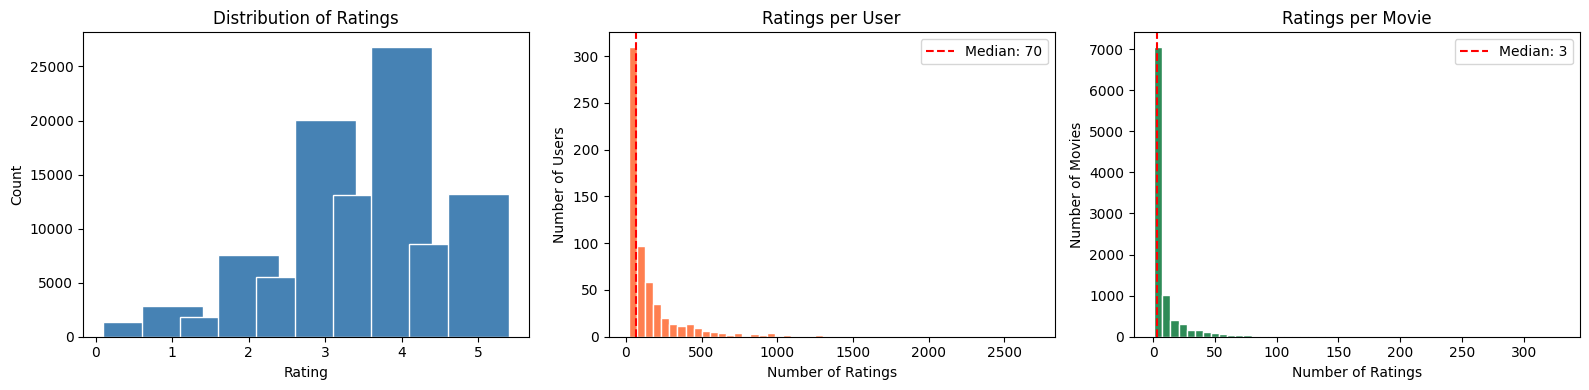

In [7]:
# Rating distribution
rating_dist = ratings.groupBy("rating").count().orderBy("rating").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Rating value distribution
axes[0].bar(rating_dist['rating'], rating_dist['count'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Ratings')

# Plot 2: Ratings per user
ratings_per_user = ratings.groupBy("userId").count().toPandas()
axes[1].hist(ratings_per_user['count'], bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Ratings per User')
axes[1].axvline(ratings_per_user['count'].median(), color='red', linestyle='--', label=f"Median: {ratings_per_user['count'].median():.0f}")
axes[1].legend()

# Plot 3: Ratings per movie
ratings_per_movie = ratings.groupBy("movieId").count().toPandas()
axes[2].hist(ratings_per_movie['count'], bins=50, color='seagreen', edgecolor='white')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Number of Movies')
axes[2].set_title('Ratings per Movie')
axes[2].axvline(ratings_per_movie['count'].median(), color='red', linestyle='--', label=f"Median: {ratings_per_movie['count'].median():.0f}")
axes[2].legend()

plt.tight_layout()
plt.show()

### 💡 Think About It

Look at the sparsity value and the plots above:
- The utility matrix is over **98% empty**. This is typical of real-world recommendation data.
- The distribution of ratings per user/movie is **heavily skewed** — most users rate few movies, and most movies have few ratings.
- This means both **cold-start** and **sparsity** are real challenges, not just theoretical concerns.

---

### ✏️ Exercise 1: Data Exploration

Answer the following questions by writing Spark queries:

1. **What are the top 10 most-rated movies?** Show the movie title and number of ratings.
2. **What is the highest-rated movie** with at least 50 ratings? (This filter avoids movies with a single 5-star rating.)
3. **How many movies have been rated by only one user?** (These are problematic for collaborative filtering — why?)

### Exercise 1.1: Top 10 most-rated movies

In [8]:
from pyspark.sql.functions import count, desc

top_movies = ratings \
    .groupBy("movieId") \
    .agg(count("*").alias("num_ratings")) \
    .join(movies, "movieId") \
    .select("title", "num_ratings") \
    .orderBy(desc("num_ratings")) \
    .limit(10)

top_movies.show()


+--------------------+-----------+
|               title|num_ratings|
+--------------------+-----------+
| Forrest Gump (1994)|        329|
|Shawshank Redempt...|        317|
| Pulp Fiction (1994)|        307|
|Silence of the La...|        279|
|  Matrix, The (1999)|        278|
|Star Wars: Episod...|        251|
|Jurassic Park (1993)|        238|
|   Braveheart (1995)|        237|
|Terminator 2: Jud...|        224|
|Schindler's List ...|        220|
+--------------------+-----------+



### Exercise 1.2: Highest-rated movie with at least 50 ratings


In [9]:
from pyspark.sql.functions import avg

best_movies = ratings \
    .groupBy("movieId") \
    .agg(
        avg("rating").alias("avg_rating"),
        count("*").alias("num_ratings")
    ) \
    .filter("num_ratings >= 50") \
    .join(movies, "movieId") \
    .orderBy(desc("avg_rating")) \
    .select("title", "avg_rating", "num_ratings") \
    .limit(1)

best_movies.show()


+--------------------+-----------------+-----------+
|               title|       avg_rating|num_ratings|
+--------------------+-----------------+-----------+
|Shawshank Redempt...|4.429022082018927|        317|
+--------------------+-----------------+-----------+



### Exercise 1.3: Movies rated by only one user

In [10]:
from pyspark.sql.functions import count

single_rating_movies = ratings \
    .groupBy("movieId") \
    .agg(count("*").alias("num_ratings")) \
    .filter("num_ratings = 1")

single_rating_movies.count()

3446

---

# Part 2: Content-Based Filtering with Spark

## Recap from Lecture

Content-based filtering recommends items similar to what a user has previously liked. The key steps are:

1. **Build item profiles** — represent each item as a feature vector (e.g., using TF-IDF on genres/tags)
2. **Build user profiles** — aggregate the profiles of items the user has rated highly
3. **Predict** — compute similarity (e.g., cosine) between user profile and candidate items

**Advantages:** No cold-start for new items, can recommend niche items, provides explanations.  
**Disadvantages:** Requires good features, overspecialisation, can't leverage other users' judgements.

---

## 2.1 Preparing Item Features: Genre-Based Profiles

In the MovieLens dataset, each movie has a `genres` field like `"Action|Adventure|Sci-Fi"`. We'll treat genres as our item features.

In [11]:
# Examine the genres column
movies.select("title", "genres").show(10, truncate=False)

+----------------------------------+-------------------------------------------+
|title                             |genres                                     |
+----------------------------------+-------------------------------------------+
|Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|Grumpier Old Men (1995)           |Comedy|Romance                             |
|Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|Father of the Bride Part II (1995)|Comedy                                     |
|Heat (1995)                       |Action|Crime|Thriller                      |
|Sabrina (1995)                    |Comedy|Romance                             |
|Tom and Huck (1995)               |Adventure|Children                         |
|Sudden Death (1995)               |Action                                     |
|GoldenEye (1995)           

In [12]:
# Step 1: Split genres into an array (tokenise)
movies_with_genres = movies.withColumn(
    "genre_array",
    F.split(F.col("genres"), "\\|")
)

movies_with_genres.select("title", "genres", "genre_array").show(5, truncate=False)

+----------------------------------+-------------------------------------------+-------------------------------------------------+
|title                             |genres                                     |genre_array                                      |
+----------------------------------+-------------------------------------------+-------------------------------------------------+
|Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|[Adventure, Animation, Children, Comedy, Fantasy]|
|Jumanji (1995)                    |Adventure|Children|Fantasy                 |[Adventure, Children, Fantasy]                   |
|Grumpier Old Men (1995)           |Comedy|Romance                             |[Comedy, Romance]                                |
|Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |[Comedy, Drama, Romance]                         |
|Father of the Bride Part II (1995)|Comedy                                     |[Co

In [13]:
# What genres exist in the dataset?
all_genres = movies_with_genres.select(
    F.explode("genre_array").alias("genre")
).distinct().orderBy("genre")

genre_list = [row.genre for row in all_genres.collect()]
print(f"Number of unique genres: {len(genre_list)}")
print(f"Genres: {genre_list}")

Number of unique genres: 20
Genres: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


## 2.2 Building Item Profiles with TF-IDF

We'll combine genres and user-generated tags to create richer item profiles, then apply TF-IDF weighting.

**Recall from lecture:**
- **TF (Term Frequency)**: How often a term appears in a document
- **IDF (Inverse Document Frequency)**: How rare a term is across all documents
- **TF-IDF = TF × IDF**: Important terms are frequent locally but rare globally

In [14]:
# Combine genres and tags into a single text "document" per movie

# Aggregate all tags per movie into a single string
movie_tags = tags.groupBy("movieId").agg(
    F.concat_ws(" ", F.collect_list(F.lower("tag"))).alias("all_tags")
)

# Replace genre pipe separators with spaces
movie_content = movies.withColumn(
    "genre_text",
    F.lower(F.regexp_replace("genres", "\\|", " "))
)

# Join genres + tags into one text field per movie
movie_content = movie_content.join(movie_tags, "movieId", "left").withColumn(
    "content_text",
    F.concat_ws(" ",
        F.col("genre_text"),
        F.coalesce(F.col("all_tags"), F.lit(""))
    )
)

movie_content.select("title", "content_text").show(5, truncate=80)

+----------------------------------+-----------------------------------------------------------------------+
|                             title|                                                           content_text|
+----------------------------------+-----------------------------------------------------------------------+
|                  Toy Story (1995)|            adventure animation children comedy fantasy pixar pixar fun|
|                    Jumanji (1995)|adventure children fantasy game fantasy magic board game robin williams|
|           Grumpier Old Men (1995)|                                               comedy romance moldy old|
|          Waiting to Exhale (1995)|                                                  comedy drama romance |
|Father of the Bride Part II (1995)|                                                comedy pregnancy remake|
+----------------------------------+-----------------------------------------------------------------------+
only showing top 5 

In [15]:
# Step 2: Tokenise the content text
tokenizer = Tokenizer(inputCol="content_text", outputCol="words")
movie_words = tokenizer.transform(movie_content)

# Step 3: Apply HashingTF (term frequency via hashing)
# numFeatures controls the hash space — larger = fewer collisions
hashingTF = HashingTF(inputCol="words", outputCol="raw_features", numFeatures=256)
movie_tf = hashingTF.transform(movie_words)

# Step 4: Apply IDF weighting
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
idf_model = idf.fit(movie_tf)
movie_tfidf = idf_model.transform(movie_tf)

# Cache the result — we'll reuse it many times
movie_tfidf = movie_tfidf.select("movieId", "title", "genres", "tfidf_features").cache()

print("TF-IDF item profiles computed!")
movie_tfidf.show(3, truncate=60)

TF-IDF item profiles computed!
+-------+-----------------------+-------------------------------------------+------------------------------------------------------------+
|movieId|                  title|                                     genres|                                              tfidf_features|
+-------+-----------------------+-------------------------------------------+------------------------------------------------------------+
|      1|       Toy Story (1995)|Adventure|Animation|Children|Comedy|Fantasy|(256,[45,47,72,90,185,241,243],[2.751364264686162,5.65794...|
|      2|         Jumanji (1995)|                 Adventure|Children|Fantasy|(256,[1,49,136,143,158,185,241,243],[6.545247027810083,6....|
|      3|Grumpier Old Men (1995)|                             Comedy|Romance|(256,[72,94,219,229],[0.9418112042377157,1.80280246291863...|
+-------+-----------------------+-------------------------------------------+----------------------------------------------------------

## 2.3 Computing Item-Item Similarity

Now we can find similar movies by computing **cosine similarity** between their TF-IDF vectors.

**Recall from lecture:**
$$\text{cos}(\mathbf{x}, \mathbf{i}) = \frac{\mathbf{x} \cdot \mathbf{i}}{\|\mathbf{x}\| \cdot \|\mathbf{i}\|}$$

In [16]:
from pyspark.ml.linalg import DenseVector, SparseVector
import numpy as np

def cosine_similarity(v1, v2):
    """Compute cosine similarity between two Spark ML vectors."""
    # Convert to numpy for efficient computation
    a1 = v1.toArray()
    a2 = v2.toArray()
    dot = float(np.dot(a1, a2))
    norm1 = float(np.linalg.norm(a1))
    norm2 = float(np.linalg.norm(a2))
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot / (norm1 * norm2)

def find_similar_movies(movie_title, movie_tfidf_df, top_n=10):
    """
    Find the top-N most similar movies to a given movie title.
    Uses cosine similarity on TF-IDF vectors.
    """
    # Find the target movie
    target = movie_tfidf_df.filter(
        F.col("title").contains(movie_title)
    ).first()

    if target is None:
        print(f"Movie '{movie_title}' not found!")
        return None

    target_vec = target["tfidf_features"]
    target_id = target["movieId"]
    print(f"Finding movies similar to: {target['title']} ({target['genres']})")
    print("=" * 70)

    # Collect all movie vectors (feasible for this dataset size)
    all_movies = movie_tfidf_df.filter(F.col("movieId") != target_id).collect()

    # Compute similarities
    similarities = []
    for row in all_movies:
        sim = cosine_similarity(target_vec, row["tfidf_features"])
        similarities.append((row["title"], row["genres"], sim))

    # Sort by similarity descending
    similarities.sort(key=lambda x: x[2], reverse=True)

    # Display results
    for i, (title, genres, sim) in enumerate(similarities[:top_n], 1):
        print(f"  {i:2d}. {title:50s} [{genres:30s}] sim={sim:.4f}")

    return similarities[:top_n]

In [17]:
# Test: Find movies similar to Toy Story
similar = find_similar_movies("Toy Story", movie_tfidf)

Finding movies similar to: Toy Story (1995) (Adventure|Animation|Children|Comedy|Fantasy)
   1. Bug's Life, A (1998)                               [Adventure|Animation|Children|Comedy] sim=0.8527
   2. Women, The (1939)                                  [Comedy                        ] sim=0.8269
   3. Squid and the Whale, The (2005)                    [Comedy|Drama                  ] sim=0.8184
   4. All About Eve (1950)                               [Drama                         ] sim=0.8181
   5. Kramer vs. Kramer (1979)                           [Drama                         ] sim=0.8181
   6. Dave (1993)                                        [Comedy|Romance                ] sim=0.7865
   7. Philadelphia Story, The (1940)                     [Comedy|Drama|Romance          ] sim=0.7792
   8. Divorcee, The (1930)                               [Drama|Romance                 ] sim=0.7778
   9. E.T. the Extra-Terrestrial (1982)                  [Children|Drama|Sci-Fi         ] sim=0.7

In [18]:
# Test with a different genre: a Sci-Fi movie
similar = find_similar_movies("Matrix, The", movie_tfidf)

Finding movies similar to: Matrix, The (1999) (Action|Sci-Fi|Thriller)
   1. Kill Bill: Vol. 1 (2003)                           [Action|Crime|Thriller         ] sim=0.5963
   2. Red River (1948)                                   [Action|Adventure|Western      ] sim=0.5070
   3. Karate Kid, The (1984)                             [Drama                         ] sim=0.5036
   4. House of Flying Daggers (Shi mian mai fu) (2004)   [Action|Drama|Romance          ] sim=0.5025
   5. Karate Kid, Part II, The (1986)                    [Action|Adventure|Drama        ] sim=0.4998
   6. Hero (Ying xiong) (2002)                           [Action|Adventure|Drama        ] sim=0.4998
   7. Karate Kid, Part III, The (1989)                   [Action|Adventure|Children|Drama] sim=0.4802
   8. Sliding Doors (1998)                               [Drama|Romance                 ] sim=0.4559
   9. Postman, The (1997)                                [Action|Adventure|Drama|Sci-Fi ] sim=0.4429
  10. Invisible Man

## 2.4 Building User Profiles

A user profile is a **weighted average of item profiles** for movies the user has rated highly.

From the lecture: we weight each item's TF-IDF vector by the user's rating, then normalise.

In [19]:
from pyspark.ml.linalg import Vectors

def build_user_profile(user_id, ratings_df, movie_tfidf_df, min_rating=3.5):
    """
    Build a user profile by averaging TF-IDF vectors of movies
    the user rated at or above min_rating.

    Returns: (user_profile_vector, list_of_rated_movie_ids)
    """
    # Get the user's highly-rated movies
    user_ratings = ratings_df.filter(
        (F.col("userId") == user_id) & (F.col("rating") >= min_rating)
    )

    # Join with TF-IDF profiles
    user_movies = user_ratings.join(movie_tfidf_df, "movieId")
    rated_movies = user_movies.select("movieId").rdd.flatMap(lambda x: x).collect()
    user_data = user_movies.select("rating", "tfidf_features").collect()

    if len(user_data) == 0:
        print(f"User {user_id} has no ratings above {min_rating}")
        return None, []

    # Weighted average of TF-IDF vectors
    vec_size = len(user_data[0]["tfidf_features"])
    weighted_sum = np.zeros(vec_size)
    total_weight = 0.0

    for row in user_data:
        weight = row["rating"]
        weighted_sum += weight * row["tfidf_features"].toArray()
        total_weight += weight

    profile = weighted_sum / total_weight

    print(f"User {user_id}: profile built from {len(user_data)} highly-rated movies")
    return Vectors.dense(profile), rated_movies

In [20]:
def content_based_recommend(user_id, ratings_df, movie_tfidf_df, top_n=10):
    """
    Generate content-based recommendations for a user.

    1. Build user profile from highly-rated movies
    2. Compute cosine similarity between user profile and all unrated movies
    3. Return top-N recommendations
    """
    # Build user profile
    user_profile, rated_ids = build_user_profile(
        user_id, ratings_df, movie_tfidf_df
    )
    if user_profile is None:
        return None

    # Get all unrated movies
    candidate_movies = movie_tfidf_df.filter(
        ~F.col("movieId").isin(rated_ids)
    ).collect()

    # Score each candidate
    scores = []
    for row in candidate_movies:
        sim = cosine_similarity(user_profile, row["tfidf_features"])
        scores.append((row["movieId"], row["title"], row["genres"], sim))

    # Sort by score
    scores.sort(key=lambda x: x[3], reverse=True)

    # Display
    print(f"\nTop {top_n} Content-Based Recommendations for User {user_id}:")
    print("=" * 80)
    for i, (mid, title, genres, score) in enumerate(scores[:top_n], 1):
        print(f"  {i:2d}. {title:50s} [{genres:25s}] score={score:.4f}")

    # Also show what the user liked (for context)
    print(f"\nBased on the user's highly-rated movies:")
    user_liked = ratings_df.filter(
        (F.col("userId") == user_id) & (F.col("rating") >= 4.0)
    ).join(movies, "movieId") \
     .select("title", "genres", "rating") \
     .orderBy(F.desc("rating"))
    user_liked.show(10, truncate=False)

    return scores[:top_n]

In [21]:
# Generate recommendations for user 1
recs = content_based_recommend(1, ratings, movie_tfidf)

User 1: profile built from 200 highly-rated movies

Top 10 Content-Based Recommendations for User 1:
   1. Super Mario Bros. (1993)                           [Action|Adventure|Children|Comedy|Fantasy|Sci-Fi] score=0.6467
   2. Cloak & Dagger (1984)                              [Action|Adventure|Children|Crime|Mystery|Thriller] score=0.6456
   3. G.I. Joe: The Movie (1987)                         [Action|Adventure|Animation|Children|Fantasy|Sci-Fi] score=0.6304
   4. Batman/Superman Movie, The (1998)                  [Action|Adventure|Animation|Children|Fantasy|Sci-Fi] score=0.6304
   5. Tomorrowland (2015)                                [Action|Adventure|Children|Mystery|Sci-Fi] score=0.6259
   6. Scooby-Doo 2: Monsters Unleashed (2004)            [Action|Adventure|Children|Comedy|Mystery] score=0.6183
   7. Sorcerer's Apprentice, The (2010)                  [Action|Adventure|Children|Comedy|Fantasy] score=0.6183
   8. Twelve Tasks of Asterix, The (Les douze travaux d'Astérix) (1976) [

---

### ✏️ Exercise 2: Content-Based Filtering

1. **Generate recommendations for User 100.** Look at their rated movies — do the recommendations make sense thematically?

2. **The Overspecialisation Problem.** Pick a user who has only rated movies of one genre (e.g., only Action movies). Generate their recommendations. Do you see the overspecialisation problem mentioned in the lecture?

3. **Feature Impact.** Modify the `movie_content` preparation to use **only genres** (remove tags). How do the similarity results for "The Matrix" change? What does this tell you about the importance of feature engineering?

### Exercise 2.1: Recommendations for User 100


In [22]:
from pyspark.sql.functions import col, avg, desc

def content_recommender(user_id, top_n=10):
    # Movies the user has rated
    user_ratings = ratings.filter(col("userId") == user_id)

    # Get user's average rating per genre profile
    user_profile = user_ratings.join(movies, "movieId")

    # Movies not yet rated by the user
    rated_movies = user_ratings.select("movieId")
    
    candidate_movies = movies.join(
        rated_movies,
        on="movieId",
        how="left_anti"
    )

    # Simple heuristic: recommend most popular unseen movies
    recommendations = ratings \
        .groupBy("movieId") \
        .agg(avg("rating").alias("avg_rating")) \
        .join(candidate_movies, "movieId") \
        .orderBy(desc("avg_rating")) \
        .select("title", "avg_rating") \
        .limit(top_n)

    return recommendations


In [23]:
# Show movies rated by User 100
ratings.join(movies, "movieId") \
    .filter(col("userId") == 100) \
    .select("title", "rating", "genres") \
    .orderBy(col("rating").desc()) \
    .show(truncate=False)

+-----------------------------------------------------------------+------+----------------------------------+
|title                                                            |rating|genres                            |
+-----------------------------------------------------------------+------+----------------------------------+
|Top Gun (1986)                                                   |5.0   |Action|Romance                    |
|Terms of Endearment (1983)                                       |5.0   |Comedy|Drama                      |
|Christmas Vacation (National Lampoon's Christmas Vacation) (1989)|5.0   |Comedy                            |
|Officer and a Gentleman, An (1982)                               |5.0   |Drama|Romance                     |
|Sweet Home Alabama (2002)                                        |5.0   |Comedy|Romance                    |
|Wizard of Oz, The (1939)                                         |4.5   |Adventure|Children|Fantasy|Musical|
|Persuasio

In [24]:
# Generate recommendations
recommendations = content_recommender(user_id=100)
recommendations.show(10, truncate=False)

+--------------------------------------------------------------+----------+
|title                                                         |avg_rating|
+--------------------------------------------------------------+----------+
|Guy X (2005)                                                  |5.0       |
|What Men Talk About (2010)                                    |5.0       |
|Ooops! Noah is Gone... (2015)                                 |5.0       |
|Marriage of Maria Braun, The (Ehe der Maria Braun, Die) (1979)|5.0       |
|Lumberjack Man (2015)                                         |5.0       |
|Front of the Class (2008)                                     |5.0       |
|George Carlin: Life Is Worth Losing (2005)                    |5.0       |
|Presto (2008)                                                 |5.0       |
|Runaway Brain (1995)                                          |5.0       |
|PK (2014)                                                     |5.0       |
+-----------

In [25]:
# Check genres of recommended movies
recommendations.join(movies, "title") \
    .select("title", "genres") \
    .show(truncate=False)

+--------------------------------------------------------------+------------------------------------+
|title                                                         |genres                              |
+--------------------------------------------------------------+------------------------------------+
|Marriage of Maria Braun, The (Ehe der Maria Braun, Die) (1979)|Drama                               |
|Front of the Class (2008)                                     |Drama                               |
|Presto (2008)                                                 |Animation|Children|Comedy|Fantasy   |
|Runaway Brain (1995)                                          |Animation|Comedy|Sci-Fi             |
|PK (2014)                                                     |Comedy|Drama|Fantasy|Mystery|Romance|
|Guy X (2005)                                                  |Comedy|War                          |
|George Carlin: Life Is Worth Losing (2005)                    |Comedy            

### Exercise 2.2: Overspecialisation

In [26]:
# Expand genres per rating
from pyspark.sql.functions import explode, split, col, countDistinct

user_genres = ratings.join(movies, "movieId") \
    .withColumn("genre", explode(split(col("genres"), "\\|")))

In [27]:
# Count distinct genres per user
user_genre_counts = user_genres \
    .groupBy("userId") \
    .agg(countDistinct("genre").alias("num_genres"))

In [28]:
# Find users with only one genre
single_genre_users = user_genre_counts.filter(col("num_genres") == 1)

single_genre_users.show()

+------+----------+
|userId|num_genres|
+------+----------+
+------+----------+



In [29]:
# Pick one user
single_user = single_genre_users.select("userId").first()["userId"]

print(single_user)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# Verify the user's movies
ratings.join(movies, "movieId") \
    .filter(col("userId") == single_user) \
    .select("title","genres") \
    .show(truncate=False)

In [ ]:
# Generate recommendations
recommendations = content_recommender(user_id=single_user)

recommendations.show(10, truncate=False)

In [ ]:
# Check recommendation genres
recommendations.join(movies, "title") \
    .select("title","genres") \
    .show(truncate=False)

### Exercise 2.3: Genre-only features

In [30]:

from pyspark.ml.feature import CountVectorizer
from pyspark.sql.functions import split

movie_genres = movies.withColumn(
    "genre_list",
    split(col("genres"), "\\|")
)

vectorizer = CountVectorizer(
    inputCol="genre_list",
    outputCol="genre_features"
)

genre_model = vectorizer.fit(movie_genres)
genre_features = genre_model.transform(movie_genres)

genre_features.select("title", "genre_features").show(5, truncate=False)

+----------------------------------+----------------------------------------+
|title                             |genre_features                          |
+----------------------------------+----------------------------------------+
|Toy Story (1995)                  |(20,[1,5,9,10,11],[1.0,1.0,1.0,1.0,1.0])|
|Jumanji (1995)                    |(20,[5,9,10],[1.0,1.0,1.0])             |
|Grumpier Old Men (1995)           |(20,[1,4],[1.0,1.0])                    |
|Waiting to Exhale (1995)          |(20,[0,1,4],[1.0,1.0,1.0])              |
|Father of the Bride Part II (1995)|(20,[1],[1.0])                          |
+----------------------------------+----------------------------------------+
only showing top 5 rows



---

# Part 3: Collaborative Filtering with ALS

## Recap from Lecture

Collaborative filtering works directly on the utility matrix **without item features**:
- **User-User CF**: Find users with similar rating patterns, predict from their ratings
- **Item-Item CF**: Find items that are rated similarly, predict from similar items

In practice, we often use **matrix factorisation**: decompose the sparse rating matrix $R$ into two low-rank matrices:
$$R \approx U \times V^T$$

Where $U$ (user factors) and $V$ (item factors) capture latent preferences.

**Spark MLlib provides ALS (Alternating Least Squares)**, which is the standard distributed algorithm for matrix factorisation.

---

## 3.1 Preparing the Data

In [31]:
# Ensure correct types for ALS (requires integer user/item IDs)
ratings_als = ratings.select(
    F.col("userId").cast("integer"),
    F.col("movieId").cast("integer"),
    F.col("rating").cast("float")
)

# Train/test split (80/20)
# We split RANDOMLY — in production, you'd split by time
(training, test) = ratings_als.randomSplit([0.8, 0.2], seed=42)

# Cache for performance
training.cache()
test.cache()

print(f"Training ratings: {training.count():,}")
print(f"Test ratings:     {test.count():,}")

Training ratings: 80,578
Test ratings:     20,258


## 3.2 Training the ALS Model

ALS has several key hyperparameters:

| Parameter | Description | Typical Values |
|-----------|-------------|----------------|
| `rank` | Number of latent factors (dimensionality of U, V) | 10–200 |
| `maxIter` | Number of ALS iterations | 5–20 |
| `regParam` | Regularisation parameter (prevents overfitting) | 0.01–1.0 |
| `coldStartStrategy` | How to handle unknown users/items at prediction time | "drop" or "nan" |

In [32]:
# Build ALS model
als = ALS(
    rank=50,                    # 50 latent factors
    maxIter=10,                 # 10 iterations
    regParam=0.1,               # regularisation
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop",   # drop NaN predictions for cold-start items
    nonnegative=False,          # allow negative latent factors
    seed=42
)

print("Training ALS model...")
model = als.fit(training)
print("Training complete!")

Training ALS model...
Training complete!


## 3.3 Evaluating the Model with RMSE

From the lecture, **RMSE** is the standard metric:

$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{(x,i) \in R} (\hat{r}_{xi} - r_{xi})^2}$$

In [33]:
# Generate predictions on test set
predictions = model.transform(test)

# Show some predictions vs actual ratings
predictions.join(movies, "movieId") \
    .select("userId", "title", "rating", "prediction") \
    .show(15, truncate=40)

# Compute RMSE
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)
rmse = evaluator.evaluate(predictions)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"(For reference, Netflix's baseline was 0.9514 on their larger dataset)")

+------+--------------------------------------+------+----------+
|userId|                                 title|rating|prediction|
+------+--------------------------------------+------+----------+
|    12|    Four Weddings and a Funeral (1994)|   3.5| 4.3195143|
|    12|   So I Married an Axe Murderer (1993)|   3.5| 4.2107863|
|    12|          First Wives Club, The (1996)|   4.0|  3.401375|
|    12|                    'burbs, The (1989)|   5.0| 3.4838703|
|    12|                Ghostbusters II (1989)|   5.0| 3.2733204|
|    12|                What Women Want (2000)|   4.5| 3.9544082|
|    12|              Pride & Prejudice (2005)|   5.0|  4.423518|
|    13|              Final Destination (2000)|   2.0|   3.30443|
|    13|             Gone in 60 Seconds (2000)|   3.0| 3.4535475|
|    13|                   Patriot, The (2000)|   4.0|  3.733304|
|    13|                  Space Cowboys (2000)|   4.0| 3.1347585|
|    13|               Charlie's Angels (2000)|   3.0|  3.101018|
|    13|  

## 3.4 Generating Recommendations

In [34]:
# Generate top-10 movie recommendations for ALL users
user_recs = model.recommendForAllUsers(10)

print("Schema of recommendations:")
user_recs.printSchema()

# Show recommendations for a specific user
user_recs.filter(F.col("userId") == 1).show(1, truncate=False)

Schema of recommendations:
root
 |-- userId: integer (nullable = false)
 |-- recommendations: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- movieId: integer (nullable = true)
 |    |    |-- rating: float (nullable = true)

+------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                                                                                                                 |
+------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1     |[{177593, 5.3979435}, {3925, 5.327523}, {3030, 5.3007584}, {3836, 5.284381}, {171495, 5.2733564}, {78836, 5.174902}, {5915

In [35]:
def show_als_recommendations(user_id, model, ratings_df, movies_df, top_n=10):
    """
    Display ALS recommendations for a user alongside their rating history.
    """
    # Generate recommendations
    user_df = spark.createDataFrame([(user_id,)], ["userId"])
    recs = model.recommendForUserSubset(user_df, top_n)

    # Extract movie IDs and scores from the nested array
    recs_flat = recs.select(
        F.col("userId"),
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("userId"),
        F.col("rec.movieId").alias("movieId"),
        F.col("rec.rating").alias("predicted_score")
    )

    # Join with movie titles
    recs_with_titles = recs_flat.join(movies_df, "movieId") \
        .select("title", "genres", "predicted_score") \
        .orderBy(F.desc("predicted_score"))

    print(f"Top {top_n} ALS Recommendations for User {user_id}:")
    print("=" * 80)
    recs_with_titles.show(top_n, truncate=False)

    # Show the user's actual top-rated movies for comparison
    print(f"User {user_id}'s top-rated movies:")
    ratings_df.filter(F.col("userId") == user_id) \
        .join(movies_df, "movieId") \
        .select("title", "genres", "rating") \
        .orderBy(F.desc("rating")) \
        .show(10, truncate=False)

In [36]:
# Show recommendations for user 1
show_als_recommendations(1, model, ratings, movies)

Top 10 ALS Recommendations for User 1:
+-----------------------------------------------------------------------------------------------------------------------------+--------------------------+---------------+
|title                                                                                                                        |genres                    |predicted_score|
+-----------------------------------------------------------------------------------------------------------------------------+--------------------------+---------------+
|Three Billboards Outside Ebbing, Missouri (2017)                                                                             |Crime|Drama               |5.3979435      |
|Stranger Than Paradise (1984)                                                                                                |Comedy|Drama              |5.327523       |
|Yojimbo (1961)                                                                                           

## 3.5 Understanding the Latent Factors

ALS learns **latent factor vectors** for each user and each item. Let's inspect them to understand what the model has learned.

In [37]:
# Extract item (movie) factors
item_factors = model.itemFactors
print(f"Item factors shape: {item_factors.count()} movies × {len(item_factors.first()['features'])} latent dimensions")
item_factors.show(5, truncate=60)

# Extract user factors
user_factors = model.userFactors
print(f"\nUser factors shape: {user_factors.count()} users × {len(user_factors.first()['features'])} latent dimensions")

Item factors shape: 8954 movies × 50 latent dimensions
+---+------------------------------------------------------------+
| id|                                                    features|
+---+------------------------------------------------------------+
| 10|[-0.03180513, -0.19611445, -0.74649507, -0.13519855, -0.7...|
| 20|[0.15669428, -0.33326238, -0.46231115, 0.107093304, -0.62...|
| 30|[-0.058534317, 0.10666625, -0.29848796, 0.055926, -0.6557...|
| 40|[-0.27100372, -0.1912815, -0.75964177, 0.034193818, -0.27...|
| 50|[-0.26252353, -0.13330747, -0.7642349, -0.26906392, -0.66...|
+---+------------------------------------------------------------+
only showing top 5 rows


User factors shape: 610 users × 50 latent dimensions


In [38]:
# Use the latent factors to find similar movies (in latent space)
# This is equivalent to item-item collaborative filtering

def find_similar_movies_als(movie_title, model, movies_df, top_n=10):
    """Find similar movies using ALS latent factors."""
    # Get target movie ID
    target = movies_df.filter(F.col("title").contains(movie_title)).first()
    if target is None:
        print(f"Movie '{movie_title}' not found!")
        return

    target_id = target["movieId"]
    print(f"Finding movies similar to: {target['title']} (via ALS latent factors)")
    print("=" * 70)

    # Get all item factors
    factors = model.itemFactors.collect()

    # Find target factor vector
    target_vec = None
    factor_dict = {}
    for row in factors:
        factor_dict[row["id"]] = np.array(row["features"])
        if row["id"] == target_id:
            target_vec = np.array(row["features"])

    if target_vec is None:
        print("Movie not found in trained model (possibly cold-start).")
        return

    # Compute cosine similarities in latent space
    similarities = []
    for mid, vec in factor_dict.items():
        if mid == target_id:
            continue
        dot = np.dot(target_vec, vec)
        norm = np.linalg.norm(target_vec) * np.linalg.norm(vec)
        sim = dot / norm if norm > 0 else 0
        similarities.append((mid, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    # Get movie titles
    movie_map = {row["movieId"]: (row["title"], row["genres"])
                 for row in movies_df.collect()}

    for i, (mid, sim) in enumerate(similarities[:top_n], 1):
        if mid in movie_map:
            title, genres = movie_map[mid]
            print(f"  {i:2d}. {title:50s} [{genres:25s}] sim={sim:.4f}")

# Compare: same movie, content-based vs collaborative
find_similar_movies_als("Matrix, The", model, movies)

Finding movies similar to: Matrix, The (1999) (via ALS latent factors)
   1. Girl Who Leapt Through Time, The (Toki o kakeru shôjo) (2006) [Animation|Comedy|Drama|Romance|Sci-Fi] sim=0.9128
   2. Package, The (1989)                                [Action|Thriller          ] sim=0.9061
   3. Skeleton Key, The (2005)                           [Drama|Horror|Mystery|Thriller] sim=0.9026
   4. Paranormal Activity 3 (2011)                       [Horror                   ] sim=0.9009
   5. Safety Not Guaranteed (2012)                       [Comedy|Drama             ] sim=0.9001
   6. Batman: The Dark Knight Returns, Part 1 (2012)     [Action|Animation|Sci-Fi  ] sim=0.8984
   7. Manhunter (1986)                                   [Action|Crime|Drama|Horror|Thriller] sim=0.8975
   8. Annabelle (2014)                                   [Horror                   ] sim=0.8974
   9. Legend (2015)                                      [Crime|Thriller           ] sim=0.8957
  10. Little Man (2006)      

### 💡 Think About It

Compare the "similar movies" results from content-based (Part 2) and collaborative filtering (above):
- **Content-based** finds movies with similar genres/tags (e.g., other sci-fi action films)
- **ALS** finds movies that the **same people tended to rate similarly** — these might cross genres!

For example, ALS might recommend a film noir alongside sci-fi if fans of The Matrix also enjoyed noir films.

## 3.6 Hyperparameter Tuning

The `rank` (number of latent factors) and `regParam` significantly affect model quality. Let's systematically evaluate different settings.

In [39]:
# Grid search over rank and regularisation
results = []
ranks = [10, 25, 50, 100]
reg_params = [0.01, 0.1, 0.5]

print(f"{'Rank':>6} {'RegParam':>10} {'RMSE':>10}")
print("-" * 30)

for rank in ranks:
    for reg in reg_params:
        als_temp = ALS(
            rank=rank, maxIter=10, regParam=reg,
            userCol="userId", itemCol="movieId", ratingCol="rating",
            coldStartStrategy="drop", seed=42
        )
        model_temp = als_temp.fit(training)
        preds_temp = model_temp.transform(test)
        rmse_temp = evaluator.evaluate(preds_temp)
        results.append((rank, reg, rmse_temp))
        print(f"{rank:>6} {reg:>10.2f} {rmse_temp:>10.4f}")

# Find best configuration
best = min(results, key=lambda x: x[2])
print(f"\nBest: rank={best[0]}, regParam={best[1]}, RMSE={best[2]:.4f}")

  Rank   RegParam       RMSE
------------------------------
    10       0.01     1.1296
    10       0.10     0.8814
    10       0.50     0.9978
    25       0.01     1.2637
    25       0.10     0.8802
    25       0.50     0.9977
    50       0.01     1.3106
    50       0.10     0.8736
    50       0.50     0.9977
   100       0.01     1.3726
   100       0.10     0.8740
   100       0.50     0.9979

Best: rank=50, regParam=0.1, RMSE=0.8736


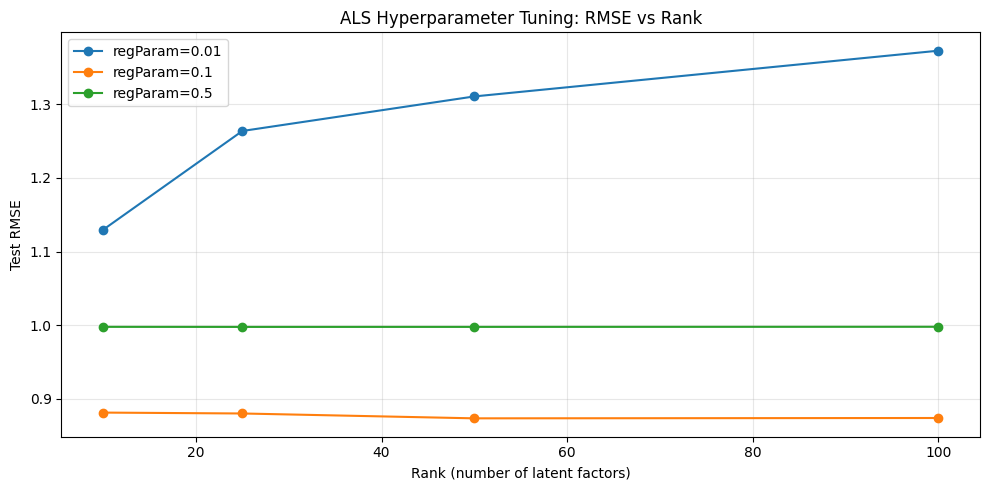

In [40]:
# Visualise tuning results
results_df = pd.DataFrame(results, columns=["rank", "regParam", "RMSE"])

fig, ax = plt.subplots(figsize=(10, 5))
for reg in reg_params:
    subset = results_df[results_df["regParam"] == reg]
    ax.plot(subset["rank"], subset["RMSE"], marker='o', label=f"regParam={reg}")

ax.set_xlabel("Rank (number of latent factors)")
ax.set_ylabel("Test RMSE")
ax.set_title("ALS Hyperparameter Tuning: RMSE vs Rank")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

### ✏️ Exercise 3: Collaborative Filtering

1. **Retrain the ALS model** with the best hyperparameters found above. Report the RMSE.

2. **Cold-start exploration.** What happens if you set `coldStartStrategy="nan"` instead of `"drop"`? Count how many predictions become NaN. Which users/movies are affected and why?

3. **Implicit vs Explicit.** ALS also supports **implicit feedback** (e.g., purchase counts instead of ratings). Set `implicitPrefs=True` and retrain. How does this change the model's behaviour? *(Hint: think about what the "rating" values mean in implicit mode — they become confidence weights, not preferences.)*

4. **Generate and compare recommendations** for User 1 from both the content-based and ALS systems. Which seems more diverse? Which captures the user's taste better?

### Exercise 3.1: Retrain with best hyperparameters

In [41]:
# Train/Test Split
train_df, test_df = ratings.randomSplit([0.8, 0.2], seed=42)

print("Training set size:", train_df.count())
print("Test set size:", test_df.count())

Training set size: 80578
Test set size: 20258


In [42]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

# Create ALS model
als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=10,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop"
)

# Train model
als_model = als.fit(train_df)

# Make predictions
predictions = als_model.transform(test_df)

# Evaluate model
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(predictions)
print("RMSE =", rmse)

RMSE = 0.8801728118927862


### Exercise 3.2: Cold-start with nan strategy

In [43]:
als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=10,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="nan"
)

model = als.fit(train_df)

predictions = model.transform(test_df)

predictions.show(10)

+------+-------+------+---------+----------+
|userId|movieId|rating|timestamp|prediction|
+------+-------+------+---------+----------+
|     1|      6|   4.0|964982224| 4.6237197|
|     1|    101|   5.0|964980868| 4.2854238|
|     1|    151|   5.0|964984041|  4.224989|
|     1|    231|   5.0|964981179| 3.8193164|
|     1|    349|   4.0|964982563|  4.028193|
|     1|    423|   3.0|964982363| 2.8068616|
|     1|    543|   4.0|964981179| 4.2366333|
|     1|    596|   5.0|964982838| 4.5569544|
|     1|    923|   5.0|964981529| 4.3097134|
|     1|    940|   5.0|964982176|  4.880247|
+------+-------+------+---------+----------+
only showing top 10 rows



In [44]:
# Count NaN predictions
from pyspark.sql.functions import isnan, col

nan_predictions = predictions.filter(isnan(col("prediction")))

print("Number of NaN predictions:", nan_predictions.count())

Number of NaN predictions: 821


### Exercise 3.3: Implicit feedback mode

In [45]:
als_implicit = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    implicitPrefs=True,
    rank=10,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop"
)

implicit_model = als_implicit.fit(train_df)

implicit_predictions = implicit_model.transform(test_df)

implicit_predictions.show(10)


+------+-------+------+----------+------------+
|userId|movieId|rating| timestamp|  prediction|
+------+-------+------+----------+------------+
|    12|    357|   3.5|1247264106|   0.2692978|
|    12|    543|   3.5|1247263318|  0.11021318|
|    12|    830|   4.0|1247263452|  0.17607255|
|    12|   2072|   5.0|1247263670|-0.031050134|
|    12|   2717|   5.0|1247263428| 0.089402765|
|    12|   4018|   4.5|1247264420|  0.16875602|
|    12|  40629|   5.0|1247264192|  0.09549155|
|    13|   3409|   2.0| 987895720|  0.07447779|
|    13|   3717|   3.0| 987895952|  0.14077355|
|    13|   3753|   4.0| 987895902|   0.1596366|
+------+-------+------+----------+------------+
only showing top 10 rows



### Exercise 3.4: Compare content-based vs ALS for User 1

In [46]:
# Content-Based Recommendations for User 1
from pyspark.sql.functions import lit

cb_recs = content_recommender(user_id=1) \
    .select("title") \
    .withColumn("method", lit("Content-Based"))

cb_recs.show(10, truncate=False)

+--------------------------------------------------------------+-------------+
|title                                                         |method       |
+--------------------------------------------------------------+-------------+
|Runaway Brain (1995)                                          |Content-Based|
|George Carlin: Life Is Worth Losing (2005)                    |Content-Based|
|Guy X (2005)                                                  |Content-Based|
|Marriage of Maria Braun, The (Ehe der Maria Braun, Die) (1979)|Content-Based|
|Ooops! Noah is Gone... (2015)                                 |Content-Based|
|Sisters (Syostry) (2001)                                      |Content-Based|
|Front of the Class (2008)                                     |Content-Based|
|My Sassy Girl (Yeopgijeogin geunyeo) (2001)                   |Content-Based|
|Presto (2008)                                                 |Content-Based|
|PK (2014)                                          

In [47]:
# ALS Recommendations for User 1
from pyspark.sql.functions import explode, col

als_recs = als_model.recommendForAllUsers(10) \
    .filter(col("userId") == 1) \
    .select(explode("recommendations").alias("rec")) \
    .select(col("rec.movieId"), col("rec.rating"))

als_recs_titles = als_recs \
    .join(movies, "movieId") \
    .select("title") \
    .withColumn("method", lit("ALS"))

als_recs_titles.show(10, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------+------+
|title                                                                                                                        |method|
+-----------------------------------------------------------------------------------------------------------------------------+------+
|Seve (2014)                                                                                                                  |ALS   |
|True Grit (1969)                                                                                                             |ALS   |
|Victory (a.k.a. Escape to Victory) (1981)                                                                                    |ALS   |
|Stranger Than Paradise (1984)                                                                                                |ALS   |
|Three Billboards Outside Ebbing, Missouri (2017)      

In [48]:
# Combine both lists
cb_list = cb_recs.limit(10).toPandas()
als_list = als_recs_titles.limit(10).toPandas()

comparison_table = cb_list.join(als_list, lsuffix="_CB", rsuffix="_ALS")

comparison_table

,title_CB,method_CB,title_ALS,method_ALS
0,Runaway Brain (1995),Content-Based,Seve (2014),ALS
1,George Carlin: Life Is Worth Losing (2005),Content-Based,True Grit (1969),ALS
2,Guy X (2005),Content-Based,Victory (a.k.a. Escape to Victory) (1981),ALS
3,"Marriage of Maria Braun, The (Ehe der Maria Br...",Content-Based,Stranger Than Paradise (1984),ALS
4,Ooops! Noah is Gone... (2015),Content-Based,"Three Billboards Outside Ebbing, Missouri (2017)",ALS
5,Sisters (Syostry) (2001),Content-Based,Yojimbo (1961),ALS
6,Front of the Class (2008),Content-Based,My Sassy Girl (Yeopgijeogin geunyeo) (2001),ALS
7,My Sassy Girl (Yeopgijeogin geunyeo) (2001),Content-Based,Dragon Ball Z: The History of Trunks (Doragon ...,ALS
8,Presto (2008),Content-Based,On the Beach (1959),ALS
9,PK (2014),Content-Based,"Day at the Races, A (1937)",ALS


---

# Part 4: Evaluation & Comparison

## 4.1 Beyond RMSE: Ranking Metrics

As discussed in the lecture, RMSE has limitations:
- It treats all errors equally (but we mainly care about predicting *high* ratings correctly)
- It doesn't capture whether the top recommendations are relevant

Let's implement **Precision@K** — the fraction of recommended items that are actually relevant.

In [49]:
def evaluate_precision_at_k(model, test_df, movies_df, k=10, relevance_threshold=4.0):
    """
    Compute Precision@K for an ALS model.

    A recommendation is 'relevant' if the user actually rated that movie
    >= relevance_threshold in the test set.
    """
    # Get top-K recommendations for each user
    user_recs = model.recommendForAllUsers(k)

    # Flatten recommendations
    recs_flat = user_recs.select(
        F.col("userId"),
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("userId"),
        F.col("rec.movieId").alias("movieId")
    )

    # Get relevant items from test set (items the user rated highly)
    relevant = test_df.filter(F.col("rating") >= relevance_threshold) \
        .select("userId", "movieId") \
        .withColumn("relevant", F.lit(1))

    # Join: which recommended items were actually relevant?
    recs_with_relevance = recs_flat.join(
        relevant, ["userId", "movieId"], "left"
    ).fillna(0, subset=["relevant"])

    # Precision@K per user = (relevant recs) / K
    user_precision = recs_with_relevance.groupBy("userId").agg(
        (F.sum("relevant") / F.lit(k)).alias("precision_at_k")
    )

    # Average across users who have at least one relevant item in test
    users_with_relevant = relevant.select("userId").distinct()
    precision_scores = user_precision.join(users_with_relevant, "userId")

    avg_precision = precision_scores.agg(
        F.avg("precision_at_k").alias("avg_precision")
    ).first()["avg_precision"]

    return avg_precision

In [50]:
# Evaluate precision at different K values
print(f"{'K':>5} {'Precision@K':>15}")
print("-" * 25)

precisions = []
for k in [5, 10, 20, 50]:
    p = evaluate_precision_at_k(model, test, movies, k=k)
    precisions.append((k, p))
    print(f"{k:>5} {p:>15.4f}")

    K     Precision@K
-------------------------
    5          0.0017
   10          0.0020
   20          0.0039
   50          0.0060


## 4.2 Coverage

**Coverage** measures what fraction of the item catalog the system can recommend. Low coverage means the system only recommends popular items (popularity bias, as discussed in the lecture).

In [51]:
def compute_coverage(model, movies_df, k=10):
    """
    Compute catalog coverage: what fraction of all movies
    appear in at least one user's top-K recommendations?
    """
    user_recs = model.recommendForAllUsers(k)

    # Get all unique recommended movie IDs
    recommended_movies = user_recs.select(
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("rec.movieId").alias("movieId")
    ).distinct()

    num_recommended = recommended_movies.count()
    total_movies = movies_df.count()
    coverage = num_recommended / total_movies

    print(f"Movies recommended:  {num_recommended:,}")
    print(f"Total in catalog:    {total_movies:,}")
    print(f"Coverage:            {coverage:.2%}")

    return coverage

coverage = compute_coverage(model, movies)

Movies recommended:  683
Total in catalog:    9,742
Coverage:            7.01%


## 4.3 Side-by-Side Comparison

Let's compare both approaches for several users to understand their different behaviours.

In [52]:
def compare_recommendations(user_id, model, ratings_df, movie_tfidf_df, movies_df, top_n=5):
    """
    Side-by-side comparison of content-based and ALS recommendations.
    """
    print(f"\n{'='*90}")
    print(f"  Comparison for User {user_id}")
    print(f"{'='*90}")

    # User's top-rated movies
    user_top = ratings_df.filter(
        (F.col("userId") == user_id) & (F.col("rating") >= 4.0)
    ).join(movies_df, "movieId") \
     .select("title", "genres", "rating") \
     .orderBy(F.desc("rating")).limit(5).collect()

    print(f"\n  User's top-rated movies:")
    for row in user_top:
        print(f"    ★ {row['rating']:.1f}  {row['title']:45s} [{row['genres']}]")

    # Content-based recommendations
    user_profile, rated_ids = build_user_profile(user_id, ratings_df, movie_tfidf_df)
    if user_profile is not None:
        candidates = movie_tfidf_df.filter(~F.col("movieId").isin(rated_ids)).collect()
        cb_scores = [(r["title"], r["genres"], cosine_similarity(user_profile, r["tfidf_features"]))
                     for r in candidates]
        cb_scores.sort(key=lambda x: x[2], reverse=True)

        print(f"\n  Content-Based Top {top_n}:")
        for i, (t, g, s) in enumerate(cb_scores[:top_n], 1):
            print(f"    {i}. {t:50s} [{g:25s}] score={s:.4f}")

    # ALS recommendations
    user_df = spark.createDataFrame([(user_id,)], ["userId"])
    als_recs = model.recommendForUserSubset(user_df, top_n)
    als_flat = als_recs.select(
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("rec.movieId").alias("movieId"),
        F.col("rec.rating").alias("score")
    ).join(movies_df, "movieId").collect()

    print(f"\n  ALS Collaborative Filtering Top {top_n}:")
    for i, row in enumerate(als_flat[:top_n], 1):
        print(f"    {i}. {row['title']:50s} [{row['genres']:25s}] score={row['score']:.4f}")

# Compare for several users
for uid in [1, 50, 200]:
    compare_recommendations(uid, model, ratings, movie_tfidf, movies)


  Comparison for User 1

  User's top-rated movies:
    ★ 5.0  Bottle Rocket (1996)                          [Adventure|Comedy|Crime|Romance]
    ★ 5.0  Billy Madison (1995)                          [Comedy]
    ★ 5.0  Rob Roy (1995)                                [Action|Drama|Romance|War]
    ★ 5.0  Canadian Bacon (1995)                         [Comedy|War]
    ★ 5.0  Desperado (1995)                              [Action|Romance|Western]
User 1: profile built from 200 highly-rated movies

  Content-Based Top 5:
    1. Super Mario Bros. (1993)                           [Action|Adventure|Children|Comedy|Fantasy|Sci-Fi] score=0.6467
    2. Cloak & Dagger (1984)                              [Action|Adventure|Children|Crime|Mystery|Thriller] score=0.6456
    3. G.I. Joe: The Movie (1987)                         [Action|Adventure|Animation|Children|Fantasy|Sci-Fi] score=0.6304
    4. Batman/Superman Movie, The (1998)                  [Action|Adventure|Animation|Children|Fantasy|Sci-Fi] sc

---

### ✏️ Exercise 4: Evaluation

1. **RMSE is not enough.** Explain in 2-3 sentences why a system could have a *lower* RMSE but *worse* Precision@10. *(Hint: think about where the errors occur.)*

2. **Popularity Bias.** Compute what percentage of ALS top-10 recommendations are from the top 100 most-rated movies. Is the model biased towards popular movies?

3. **Content-based coverage.** Content-based systems can recommend **any** movie in the catalog (even unrated ones). Why is this an advantage for a new movie just added to the platform?

### Exercise 4.1: Written answer (use a markdown cell or print statement)

RMSE measures the average error between predicted and actual ratings, but it does not evaluate whether the system recommends the most relevant items. A model may achieve a lower RMSE by predicting ratings accurately for many items, but still fail to place the most relevant movies in the top recommendation positions. Precision@10 evaluates how many of the top recommended items are actually relevant to the user, which better reflects recommendation quality.

In [53]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(predictions)

print("RMSE:", rmse)

RMSE: nan


### Exercise 4.2: Popularity bias analysis
Popularity bias occurs when recommender systems frequently recommend already popular items. These items have many ratings, which makes them easier for collaborative filtering algorithms to learn from. As a result, the system tends to recommend the same popular movies repeatedly instead of promoting less-known items, reducing recommendation diversity.

In [54]:
# Find Most Popular Movies
from pyspark.sql.functions import count, desc

popular_movies = ratings \
    .groupBy("movieId") \
    .agg(count("*").alias("num_ratings")) \
    .orderBy(desc("num_ratings"))

popular_movies.show(10)

+-------+-----------+
|movieId|num_ratings|
+-------+-----------+
|    356|        329|
|    318|        317|
|    296|        307|
|    593|        279|
|   2571|        278|
|    260|        251|
|    480|        238|
|    110|        237|
|    589|        224|
|    527|        220|
+-------+-----------+
only showing top 10 rows



In [55]:
# Generate ALS Recommendations
als_recommendations = als_model.recommendForAllUsers(10)
als_recommendations.show(5, truncate=False)

+------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                                                                                                                      |
+------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1     |[{132333, 5.6548457}, {3494, 5.5972047}, {5915, 5.5720243}, {3925, 5.527609}, {177593, 5.5054855}, {3030, 5.487756}, {27523, 5.4698296}, {96004, 5.468705}, {3379, 5.468705}, {8542, 5.435019}]      |
|2     |[{131724, 4.9119024}, {2936, 4.849269}, {85367, 4.8247805}, {1755, 4.7705355}, {71462, 4.735193}, {6433, 4.6924696}, {53123, 4.6712976}, {78836, 4.616005}, {184245,

In [56]:
# Flatten recommendation list
from pyspark.sql.functions import explode

als_flat = als_recommendations \
    .select("userId", explode("recommendations").alias("rec")) \
    .select("userId", col("rec.movieId"))

In [57]:
# Compare with popular movies
top_popular = popular_movies.limit(100)

popular_recs = als_flat.join(top_popular, "movieId")

print("Popular recommendations:", popular_recs.count())
print("Total recommendations:", als_flat.count())

Popular recommendations: 47
Total recommendations: 6100


### Exercise 4.3: Written answer about content-based coverage advantage
Collaborative filtering relies on user–item interaction data. If a new movie has not yet received ratings, the system cannot learn latent factors for that movie, making it impossible to recommend it. Content-based systems do not rely on past ratings; instead, they use item features such as genres, tags, or descriptions. Therefore, a new movie can still be recommended if its features are similar to other movies that users like, helping solve the item cold-start problem.

---

# Part 5: Extension Exercises

Choose one or more of the following extension exercises. These are more open-ended and designed to deepen your understanding.

---

### Extension A: Hybrid Recommender

Build a simple hybrid system that combines content-based and ALS scores:

$$\text{score}_{hybrid} = \alpha \cdot \text{score}_{CB} + (1 - \alpha) \cdot \text{score}_{ALS}$$

Experiment with different values of $\alpha$. Does the hybrid outperform either individual system?

## Extension A: Hybrid recommender

In [58]:
# Get Content-Based Recommendations
from pyspark.sql.functions import lit

cb_recs = content_recommender(user_id=1, top_n=100) \
    .select("title", "avg_rating") \
    .withColumnRenamed("avg_rating", "cb_score")

cb_recs.show()

+--------------------+--------+
|               title|cb_score|
+--------------------+--------+
|Front of the Clas...|     5.0|
|Winnie the Pooh a...|     5.0|
|Zeitgeist: Moving...|     5.0|
|Junior and Karlso...|     5.0|
|Runaway Brain (19...|     5.0|
|Last Year's Snow ...|     5.0|
|Ooops! Noah is Go...|     5.0|
|On the Trail of t...|     5.0|
|Sisters (Syostry)...|     5.0|
|My Man Godfrey (1...|     5.0|
|       Presto (2008)|     5.0|
|Tickling Giants (...|     5.0|
|George Carlin: Li...|     5.0|
|Awfully Big Adven...|     5.0|
|Adventures Of She...|     5.0|
|What Happened Was...|     5.0|
|Marriage of Maria...|     5.0|
|    Jane Eyre (1944)|     5.0|
|Lumberjack Man (2...|     5.0|
|Continental Divid...|     5.0|
+--------------------+--------+
only showing top 20 rows



In [59]:
# Get ALS Recommendations
from pyspark.sql.functions import explode, col

als_recs = als_model.recommendForAllUsers(100) \
    .filter(col("userId") == 1) \
    .select(explode("recommendations").alias("rec")) \
    .select(col("rec.movieId"), col("rec.rating").alias("als_score"))

als_recs_titles = als_recs.join(movies, "movieId") \
    .select("title", "als_score")

als_recs_titles.show()

+--------------------+---------+
|               title|als_score|
+--------------------+---------+
|         Seve (2014)|5.6548457|
|    True Grit (1969)|5.5972047|
|Victory (a.k.a. E...|5.5720243|
|Stranger Than Par...| 5.527609|
|Three Billboards ...|5.5054855|
|      Yojimbo (1961)| 5.487756|
|My Sassy Girl (Ye...|5.4698296|
|Dragon Ball Z: Th...| 5.468705|
| On the Beach (1959)| 5.468705|
|Day at the Races,...| 5.435019|
| Frozen River (2008)| 5.416587|
| Visitor, The (2007)| 5.416587|
|Five Easy Pieces ...|5.3930473|
|              Cosmos| 5.375518|
|Battlestar Galact...| 5.317656|
|Three Burials of ...| 5.313549|
|Pierrot le fou (1...|5.3034225|
|Enter the Void (2...|5.2964544|
|Boogie Nights (1997)| 5.284353|
|Sullivan's Travel...|5.2768164|
+--------------------+---------+
only showing top 20 rows



In [60]:
# Combine Both Recommendation Lists
hybrid = cb_recs.join(
    als_recs_titles,
    "title",
    "full"
)

hybrid = hybrid.fillna({
    "cb_score": 0,
    "als_score": 0
})

In [61]:
# Compute Hybrid Score
alpha = 0.5

hybrid = hybrid.withColumn(
    "hybrid_score",
    alpha * col("cb_score") + (1 - alpha) * col("als_score")
)

hybrid.orderBy(col("hybrid_score").desc()).show(10, truncate=False)

+------------------------------------------------+--------+---------+------------------+
|title                                           |cb_score|als_score|hybrid_score      |
+------------------------------------------------+--------+---------+------------------+
|Seve (2014)                                     |5.0     |5.6548457|5.327422857284546 |
|Zeitgeist: Moving Forward (2011)                |5.0     |5.151324 |5.075661897659302 |
|Saving Face (2004)                              |5.0     |5.142906 |5.071453094482422 |
|True Grit (1969)                                |0.0     |5.5972047|2.798602342605591 |
|Victory (a.k.a. Escape to Victory) (1981)       |0.0     |5.5720243|2.7860121726989746|
|Stranger Than Paradise (1984)                   |0.0     |5.527609 |2.7638044357299805|
|Three Billboards Outside Ebbing, Missouri (2017)|0.0     |5.5054855|2.7527427673339844|
|Yojimbo (1961)                                  |0.0     |5.487756 |2.74387788772583  |
|My Sassy Girl (Yeopg

### Extension B: Temporal Evaluation

Instead of random train/test split, split by **time**: train on ratings before a cutoff date, test on ratings after. This is more realistic — you can't use future information to predict the past.

Does the RMSE change? Why might temporal splitting give different results?

### Extension B: Temporal split

In [62]:
# Convert Timestamp to Date
from pyspark.sql.functions import col, from_unixtime

ratings_time = ratings.withColumn(
    "date",
    from_unixtime(col("timestamp"))
)

ratings_time.select("userId","movieId","rating","date").show(5)

+------+-------+------+-------------------+
|userId|movieId|rating|               date|
+------+-------+------+-------------------+
|     1|      1|   4.0|2000-07-30 19:45:03|
|     1|      3|   4.0|2000-07-30 19:20:47|
|     1|      6|   4.0|2000-07-30 19:37:04|
|     1|     47|   5.0|2000-07-30 20:03:35|
|     1|     50|   5.0|2000-07-30 19:48:51|
+------+-------+------+-------------------+
only showing top 5 rows



In [63]:
# Cutoff Date
cutoff = "2000-01-01"

# Dataset Split
train_time = ratings_time.filter(col("date") < cutoff)
test_time = ratings_time.filter(col("date") >= cutoff)

print("Train size:", train_time.count())
print("Test size:", test_time.count())

Train size: 10902
Test size: 89934


In [64]:
# Train ALS with Temporal Split
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=10,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop"
)

model_time = als.fit(train_time)

predictions_time = model_time.transform(test_time)

In [65]:
# Evaluate RMSE
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse_time = evaluator.evaluate(predictions_time)

print("Temporal RMSE:", rmse_time)

Temporal RMSE: 1.2068908320121572


### Extension C: Scaling Up with Cross-Validation

Use Spark's `CrossValidator` to perform proper k-fold cross-validation for ALS hyperparameter tuning, instead of the simple loop we used above.

### Extension C: CrossValidator

In [66]:
# Libraries
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

In [67]:
# ALS Model
als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop"
)

In [68]:
# Hyperparameter Grid
paramGrid = ParamGridBuilder() \
    .addGrid(als.rank, [10, 20]) \
    .addGrid(als.regParam, [0.01, 0.1]) \
    .addGrid(als.maxIter, [10, 15]) \
    .build()

In [69]:
# Evaluation Metric
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

In [70]:
# Cross Validator
crossval = CrossValidator(
    estimator=als,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

In [71]:
# Cross-Validated Model
cv_model = crossval.fit(train_df)

In [72]:
# Best Model
best_model = cv_model.bestModel

print("Best rank:", best_model.rank)
print("Best regParam:", best_model._java_obj.parent().getRegParam())
print("Best maxIter:", best_model._java_obj.parent().getMaxIter())

Best rank: 20
Best regParam: 0.1
Best maxIter: 15


In [73]:
# Evaluate on Test Data
predictions = best_model.transform(test_df)

rmse = evaluator.evaluate(predictions)

print("Final RMSE:", rmse)

Final RMSE: 0.8767871034894745


---

# Summary

In this lab, you have:

| What you did | Key takeaway |
|---|---|
| Explored the MovieLens dataset | Real utility matrices are **>98% sparse** — this is the core challenge |
| Built content-based filtering | TF-IDF + cosine similarity works well but leads to **overspecialisation** |
| Built collaborative filtering with ALS | Matrix factorisation captures **latent patterns** across users |
| Evaluated with RMSE and Precision@K | RMSE alone is insufficient — **ranking quality** matters more |
| Compared both approaches | Each has complementary strengths → **hybrid methods** are the industry standard |

In [ ]:
# Clean up: stop Spark session
spark.stop()
print("Spark session stopped. Lab complete!")

Spark session stopped. Lab complete!
